In [5]:
import psi4
import numpy as np

In [6]:
psi4.set_memory('2 GB')
psi4.set_num_threads(2)

he_he_template = """He 0.0 0.0 0.0
--
He 0.0 0.0 {R}"""

# Basis set
basis_set = 'aug-cc-pVTZ'

# List of distances (in Angstroms)
distances = np.logspace(np.log10(1.4),np.log10(8),25) 

# Loop over distances
energies_he_2 = []
for R in distances:
    # Create the molecule at the current distance
    mol = psi4.geometry(he_he_template.format(R=R))
    mol.update_geometry()
#    mol.print_out()

    # Set the basis set
    psi4.set_options({'basis': basis_set})
    psi4.set_output_file("outfile.txt")

    # Compute the energy
    energy = psi4.energy('MP2', molecule=mol, bsse_type = 'cp')
    energies_he_2.append(energy)
    
    # Write to the output file
    print(f"{R:.2f} {energy:.8f}", file=open('He_2_PEC.dat', 'a'))

(-20.0, 20.0)

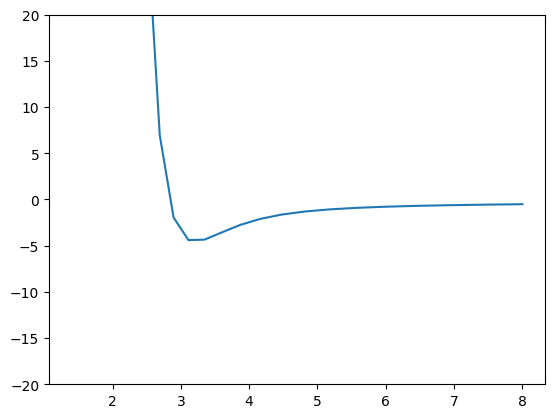

In [7]:
import matplotlib.pyplot as plt
plt.plot( distances, np.array(energies_he_2)*219474.63)
plt.ylim((-20,20))
